In [ ]:
# ============================================================
# PlantVillage 10% Multi-Seed Verification
# Runs seeds [123, 456]; aggregates with existing seed 42 results
# ============================================================
import os, sys, random, copy, time, json, csv, platform
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Torchvision:   {torchvision.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device:        {device}")
if torch.cuda.is_available():
    print(f"GPU:           {torch.cuda.get_device_name(0)}")

# ===== Hyperparameters (identical to original PV notebook) =====
LABEL_PCT       = 0.10
VAL_PCT         = 0.10
IMG_SIZE        = 224
BATCH_SIZE      = 128
NUM_WORKERS     = 2

# SimCLR (already trained — we just load the checkpoint)
SIMCLR_TEMP     = 0.5

# MixMatch
K_AUGMENTS      = 2
SHARPEN_TEMP    = 0.5
MIXUP_ALPHA     = 0.75
LAMBDA_U        = 1.0

# Training
EPOCHS_DEFAULT  = 30
LR_SUP          = 1e-3   # B1
LR_PRETRAINED   = 1e-4   # B3, B4, B5

print(f"\nHyperparameters set (matching original PV notebook).")

Python:        3.12.13
PyTorch:       2.11.0+cu128
Torchvision:   0.26.0+cu128
Device:        cuda
GPU:           Tesla T4

Hyperparameters set (matching original PV notebook).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = "/content/drive/MyDrive/Tomato_3regime"
RESULTS_DIR     = f"{PROJECT_DIR}/RESULTS 2"
SIMCLR_CKPT_SRC = f"{RESULTS_DIR}/simclr/simclr_checkpoint.pth"

assert os.path.exists(SIMCLR_CKPT_SRC), \
    f"SimCLR checkpoint not found at {SIMCLR_CKPT_SRC} — run the main PV notebook first."
print(f"✓ SimCLR checkpoint OK: {SIMCLR_CKPT_SRC}")

# Verify seed 42 results exist (we'll aggregate them with new seeds)
SEED42_PATH = f"{RESULTS_DIR}/10pct"
seed42_methods = ["B1_supervised", "B3_self_supervised",
                  "B4_semi_supervised", "B5_hybrid"]
missing = [m for m in seed42_methods
           if not os.path.exists(f"{SEED42_PATH}/{m}/metrics.json")]
if missing:
    print(f"⚠ Missing seed-42 results for: {missing}")
    print(f"  (Aggregation cell will skip them. New seeds 123/456 will still run.)")
else:
    print(f"✓ Seed-42 results found at: {SEED42_PATH}")

Mounted at /content/drive
✓ SimCLR checkpoint OK: /content/drive/MyDrive/Tomato_3regime/RESULTS 2/simclr/simclr_checkpoint.pth
✓ Seed-42 results found at: /content/drive/MyDrive/Tomato_3regime/RESULTS 2/10pct


In [ ]:
# Colab's local disk is wiped on disconnect, so we rebuild it.
# This downloads PlantVillage from Kaggle if not already present.

if not os.path.exists("/content/TomatoDataset"):
    # Try Kaggle download
    if not os.path.exists("/content/PlantVillage"):
        !pip install -q kaggle
        from google.colab import files
        print("Upload kaggle.json (Kaggle → Account → Create API Token):")
        files.upload()
        !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
        !kaggle datasets download -d emmarex/plantdisease
        !unzip -q plantdisease.zip -d /content/
        print("Dataset downloaded.")

    import shutil
    DATASET_PATH = "/content/PlantVillage"
    TOMATO_PATH  = "/content/TomatoDataset"
    tomato_classes = sorted([c for c in os.listdir(DATASET_PATH) if c.startswith("Tomato")])
    os.makedirs(TOMATO_PATH, exist_ok=True)
    for cls in tomato_classes:
        shutil.copytree(os.path.join(DATASET_PATH, cls), os.path.join(TOMATO_PATH, cls))
    print(f"Tomato subset created at {TOMATO_PATH}")
else:
    TOMATO_PATH = "/content/TomatoDataset"
    print(f"Tomato subset already present at {TOMATO_PATH}")

# Verify
classes_found = sorted([d for d in os.listdir(TOMATO_PATH)
                        if os.path.isdir(os.path.join(TOMATO_PATH, d))])
total = sum(len(os.listdir(os.path.join(TOMATO_PATH, c))) for c in classes_found)
print(f"\nFound {len(classes_found)} class folders, {total} total images")
for c in classes_found:
    n = len(os.listdir(os.path.join(TOMATO_PATH, c)))
    print(f"  {c:<35} {n:>5}")

Upload kaggle.json (Kaggle → Account → Create API Token):


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:37<00:00, 18.3MB/s]

Dataset downloaded.
Tomato subset created at /content/TomatoDataset

Found 10 class folders, 16012 total images
  Tomato_Bacterial_spot                2127
  Tomato_Early_blight                  1000
  Tomato_Late_blight                   1909
  Tomato_Leaf_Mold                      952
  Tomato_Septoria_leaf_spot            1771
  Tomato_Spider_mites_Two_spotted_spider_mite  1676
  Tomato__Target_Spot                  1404
  Tomato__Tomato_YellowLeaf__Curl_Virus  3209
  Tomato__Tomato_mosaic_virus           373
  Tomato_healthy                       1591


In [ ]:
# Transforms (matching original PV notebook)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
weak_transform = train_transform

class LabeledSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset; self.indices = indices; self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

class UnlabeledKAug(Dataset):
    def __init__(self, base_dataset, indices, transform, K=2):
        self.base = base_dataset; self.indices = indices
        self.transform = transform; self.K = K
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        path, _ = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return [self.transform(img) for _ in range(self.K)]

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def empty_cache():
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def sharpen(p, T=0.5):
    p = p.pow(1.0 / T)
    return p / p.sum(dim=1, keepdim=True)

def mixup(x1, y1, x2, y2, alpha=0.75):
    lam = np.random.beta(alpha, alpha); lam = max(lam, 1 - lam)
    return lam * x1 + (1 - lam) * x2, lam * y1 + (1 - lam) * y2

def stratified_split_with_floor(dataset, label_pct=0.10, val_pct=0.10,
                                 min_per_class=10, seed=42):
    rng = random.Random(seed)
    class_indices = {}
    for idx in range(len(dataset)):
        _, label = dataset.samples[idx]
        class_indices.setdefault(label, []).append(idx)
    labeled_idx, unlabeled_idx, val_idx = [], [], []
    for label, indices in class_indices.items():
        rng.shuffle(indices)
        n = len(indices)
        n_label = max(min_per_class, int(label_pct * n))
        n_val   = max(min_per_class, int(val_pct * n))
        labeled_idx.extend(indices[:n_label])
        val_idx.extend(indices[n_label:n_label + n_val])
        unlabeled_idx.extend(indices[n_label + n_val:])
    return labeled_idx, unlabeled_idx, val_idx

# Build base dataset
base_dataset = ImageFolder(root=TOMATO_PATH)
NUM_CLASSES = len(base_dataset.classes)
print(f"Classes ({NUM_CLASSES}): {base_dataset.classes}")
print(f"Total images: {len(base_dataset)}")

Classes (10): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total images: 16011


In [ ]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        y_pred.append(model(imgs).argmax(1).cpu().numpy())
        y_true.append(labels.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)

def plot_confusion_matrix(cm, class_names, save_path, title="Confusion Matrix"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, mat, sub, fmt in [(axes[0], cm, "Counts", "d"),
                              (axes[1], cm_norm, "Normalized", ".2f")]:
        im = ax.imshow(mat, cmap="Blues", aspect="auto")
        ax.set_title(f"{title} — {sub}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels([c[:20] for c in class_names], rotation=45, ha="right")
        ax.set_yticklabels([c[:20] for c in class_names])
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat[i, j]
                color = "white" if v > mat.max() * 0.55 else "black"
                ax.text(j, i, format(v, fmt), ha="center", va="center", color=color, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.close(fig)

def plot_training_curves(history, save_path, method_name):
    epochs = history.get("epoch", [])
    has_lx = "loss_x" in history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if has_lx:
        axes[0].plot(epochs, history["loss_x"], marker="o", label="labeled (lx)")
        axes[0].plot(epochs, history["loss_u"], marker="s", label="unlabeled (lu)")
    else:
        axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{method_name} — training loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history["val_acc"], marker="o", color="tab:green")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val accuracy (%)")
    axes[1].set_title(f"{method_name} — validation accuracy"); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.close(fig)

def full_evaluation(model, loader, class_names, method_name, history, out_dir, pct_tag, seed_val):
    os.makedirs(out_dir, exist_ok=True)
    y_true, y_pred = collect_predictions(model, loader, device)
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    p_cls, r_cls, f1_cls, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    acc_cls = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    metrics = {
        "method": method_name, "pct_tag": pct_tag, "seed": seed_val,
        "overall": {
            "accuracy": float(acc),
            "precision_macro": float(p_macro), "recall_macro": float(r_macro),
            "f1_macro": float(f1_macro),
            "precision_weighted": float(p_weight), "recall_weighted": float(r_weight),
            "f1_weighted": float(f1_weight),
        },
        "per_class": {
            "class_names": list(class_names),
            "accuracy": acc_cls.tolist(), "precision": p_cls.tolist(),
            "recall": r_cls.tolist(), "f1": f1_cls.tolist(), "support": support.tolist(),
        },
        "confusion_matrix": cm.tolist(),
        "history": history,
        "best_val_acc": max(history.get("val_acc", [0.0])),
    }
    with open(f"{out_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
    report = classification_report(y_true, y_pred, labels=range(len(class_names)),
                                    target_names=class_names, digits=4, zero_division=0)
    with open(f"{out_dir}/classification_report.txt", "w") as f:
        f.write(f"Method: {method_name}   Label %: {pct_tag}   Seed: {seed_val}\n")
        f.write("=" * 80 + "\n"); f.write(report)
        f.write("\n\nConfusion matrix (rows=true, cols=pred):\n"); f.write(str(cm))
    plot_confusion_matrix(cm, class_names, f"{out_dir}/confusion_matrix.png",
                          title=f"{method_name} @ {pct_tag} seed={seed_val}")
    plot_training_curves(history, f"{out_dir}/training_curves.png",
                         f"{method_name} @ {pct_tag} seed={seed_val}")
    return metrics

print("Metrics utilities loaded.")

Metrics utilities loaded.


In [ ]:
class SimCLRModel(nn.Module):
    def __init__(self, feature_dim=128, init="imagenet"):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if init == "imagenet" else None
        self.encoder = models.resnet18(weights=weights)
        self.encoder.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(inplace=True),
            nn.Linear(256, feature_dim),
        )
    def forward(self, x):
        h = self.encoder(x); z = self.projector(h)
        return h, z

simclr_ckpt = torch.load(SIMCLR_CKPT_SRC, map_location=device, weights_only=False)
print(f"SimCLR checkpoint loaded.")
if "final_loss" in simclr_ckpt:
    print(f"  Final NT-Xent loss: {simclr_ckpt['final_loss']:.4f}")
if "epoch" in simclr_ckpt:
    print(f"  Epochs trained:     {simclr_ckpt['epoch']}")

SimCLR checkpoint loaded.
  Final NT-Xent loss: 3.7202
  Epochs trained:     10


In [ ]:
# ==============================================================================
# MULTI-SEED SWEEP — PlantVillage 10% labels, seeds 123 and 456
# Seed 42 was done in the main notebook. We aggregate all three in Cell 8.
# ==============================================================================
SEEDS_TO_RUN = [123, 456]

print(f"PlantVillage 10% Multi-Seed Verification")
print(f"Seeds to run: {SEEDS_TO_RUN}  (seed 42 already done in main notebook)\n")

overall_start = time.time()

for SEED_CUR in SEEDS_TO_RUN:
    print("\n" + "█" * 80)
    print(f"█  PV 10pct  ·  SEED {SEED_CUR}")
    print("█" * 80)

    pct_tag = "10pct"
    CUR_OUT = f"{RESULTS_DIR}/{pct_tag}_seed{SEED_CUR}"
    for method in ["B1_supervised", "B3_self_supervised",
                   "B4_semi_supervised", "B5_hybrid"]:
        os.makedirs(f"{CUR_OUT}/{method}", exist_ok=True)
    os.makedirs(f"{RESULTS_DIR}/splits", exist_ok=True)

    # Build split with this seed
    set_seed(SEED_CUR)
    labeled_idx, unlabeled_idx, val_idx = stratified_split_with_floor(
        base_dataset, label_pct=LABEL_PCT, val_pct=VAL_PCT,
        min_per_class=10, seed=SEED_CUR,
    )
    total_n = len(base_dataset)
    print(f"  Split: lab={len(labeled_idx)} ({100*len(labeled_idx)/total_n:.2f}%)  "
          f"unl={len(unlabeled_idx)} ({100*len(unlabeled_idx)/total_n:.2f}%)  "
          f"val={len(val_idx)} ({100*len(val_idx)/total_n:.2f}%)")

    with open(f"{RESULTS_DIR}/splits/split_{pct_tag}_seed{SEED_CUR}.json", "w") as f:
        json.dump({"seed": SEED_CUR, "label_pct": LABEL_PCT, "val_pct": VAL_PCT,
                   "labeled_idx": labeled_idx, "unlabeled_idx": unlabeled_idx,
                   "val_idx": val_idx, "classes": base_dataset.classes}, f)

    labeled_dataset   = LabeledSubset(base_dataset, labeled_idx,   weak_transform)
    unlabeled_dataset = UnlabeledKAug(base_dataset, unlabeled_idx, weak_transform, K=K_AUGMENTS)
    val_dataset       = LabeledSubset(base_dataset, val_idx,       eval_transform)
    labeled_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    train_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

    # ===== B1: Supervised =====
    set_seed(SEED_CUR)
    sup_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    sup_model.fc = nn.Linear(512, NUM_CLASSES); sup_model = sup_model.to(device)
    optimizer = torch.optim.Adam(sup_model.parameters(), lr=LR_SUP)
    criterion = nn.CrossEntropyLoss()
    hist = {"epoch": [], "train_loss": [], "val_acc": []}
    best, best_state = 0.0, None
    print(f"  Training B1 (seed {SEED_CUR})...", end="", flush=True)
    t0 = time.time()
    for epoch in range(EPOCHS_DEFAULT):
        sup_model.train(); tl, nb = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(sup_model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tl += loss.item(); nb += 1
        sup_model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (sup_model(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        hist["epoch"].append(epoch+1); hist["train_loss"].append(tl/nb); hist["val_acc"].append(val_acc)
        if val_acc > best: best = val_acc; best_state = copy.deepcopy(sup_model.state_dict())
    sup_model.load_state_dict(best_state)
    full_evaluation(sup_model, val_loader, base_dataset.classes, "B1_supervised",
                    hist, f"{CUR_OUT}/B1_supervised", pct_tag, SEED_CUR)
    print(f" best={best:.2f}%  ({(time.time()-t0)/60:.1f}m)")
    del sup_model, optimizer; empty_cache()

    # ===== B3: SimCLR + Full FT =====
    set_seed(SEED_CUR)
    simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])
    class SimCLRFineTune(nn.Module):
        def __init__(self, enc, n):
            super().__init__(); self.encoder = copy.deepcopy(enc); self.classifier = nn.Linear(512, n)
        def forward(self, x): return self.classifier(self.encoder(x))
    ft_model = SimCLRFineTune(simclr_clean.encoder, NUM_CLASSES).to(device)
    optimizer = torch.optim.Adam(ft_model.parameters(), lr=LR_PRETRAINED)
    criterion = nn.CrossEntropyLoss()
    hist = {"epoch": [], "train_loss": [], "val_acc": []}
    best, best_state = 0.0, None
    print(f"  Training B3 (seed {SEED_CUR})...", end="", flush=True)
    t0 = time.time()
    for epoch in range(EPOCHS_DEFAULT):
        ft_model.train(); tl, nb = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(ft_model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tl += loss.item(); nb += 1
        ft_model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (ft_model(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        hist["epoch"].append(epoch+1); hist["train_loss"].append(tl/nb); hist["val_acc"].append(val_acc)
        if val_acc > best: best = val_acc; best_state = copy.deepcopy(ft_model.state_dict())
    ft_model.load_state_dict(best_state)
    full_evaluation(ft_model, val_loader, base_dataset.classes, "B3_self_supervised",
                    hist, f"{CUR_OUT}/B3_self_supervised", pct_tag, SEED_CUR)
    print(f" best={best:.2f}%  ({(time.time()-t0)/60:.1f}m)")
    del ft_model, optimizer, simclr_clean; empty_cache()

    # ===== B4: MixMatch =====
    set_seed(SEED_CUR)
    mm_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    mm_model.fc = nn.Linear(512, NUM_CLASSES); mm_model = mm_model.to(device)
    optimizer = torch.optim.Adam(mm_model.parameters(), lr=LR_PRETRAINED)
    hist = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
    best, best_state = 0.0, None
    print(f"  Training B4 (seed {SEED_CUR})...", end="", flush=True)
    t0 = time.time()
    for epoch in range(EPOCHS_DEFAULT):
        mm_model.train(); tlx, tlu, nb = 0.0, 0.0, 0
        uiter = iter(unlabeled_loader)
        for bx, by in labeled_loader:
            try: buv = next(uiter)
            except StopIteration: uiter = iter(unlabeled_loader); buv = next(uiter)
            bx, by = bx.to(device), by.to(device); buv = [v.to(device) for v in buv]
            with torch.no_grad():
                probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
                for v in buv: probs += F.softmax(mm_model(v), dim=1)
                probs /= len(buv); pseudo = sharpen(probs, T=SHARPEN_TEMP)
            loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
            ai = torch.cat([bx]+buv, dim=0); at = torch.cat([loh]+[pseudo]*len(buv), dim=0)
            si = torch.randperm(ai.size(0))
            mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)
            n = bx.size(0); xp, yp = mx[:n], my[:n]; up, uy = mx[n:], my[n:]
            lx = -torch.mean(torch.sum(yp * F.log_softmax(mm_model(xp), dim=1), dim=1))
            lu = F.mse_loss(F.softmax(mm_model(up), dim=1), uy)
            loss = lx + LAMBDA_U * lu
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tlx += lx.item(); tlu += lu.item(); nb += 1
        mm_model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (mm_model(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        hist["epoch"].append(epoch+1); hist["loss_x"].append(tlx/nb)
        hist["loss_u"].append(tlu/nb); hist["val_acc"].append(val_acc)
        if val_acc > best: best = val_acc; best_state = copy.deepcopy(mm_model.state_dict())
    mm_model.load_state_dict(best_state)
    full_evaluation(mm_model, val_loader, base_dataset.classes, "B4_semi_supervised",
                    hist, f"{CUR_OUT}/B4_semi_supervised", pct_tag, SEED_CUR)
    print(f" best={best:.2f}%  ({(time.time()-t0)/60:.1f}m)")
    del mm_model, optimizer; empty_cache()

    # ===== B5: Hybrid (TOM-CSSL) =====
    set_seed(SEED_CUR)
    simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])
    class SimCLRMixMatchFull(nn.Module):
        def __init__(self, enc, n):
            super().__init__(); self.encoder = copy.deepcopy(enc); self.classifier = nn.Linear(512, n)
        def forward(self, x): return self.classifier(self.encoder(x))
    b5 = SimCLRMixMatchFull(simclr_clean.encoder, NUM_CLASSES).to(device)
    optimizer = torch.optim.Adam(b5.parameters(), lr=LR_PRETRAINED)
    hist = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
    best, best_state = 0.0, None
    print(f"  Training B5 (seed {SEED_CUR})...", end="", flush=True)
    t0 = time.time()
    for epoch in range(EPOCHS_DEFAULT):
        b5.train(); tlx, tlu, nb = 0.0, 0.0, 0
        uiter = iter(unlabeled_loader)
        for bx, by in labeled_loader:
            try: buv = next(uiter)
            except StopIteration: uiter = iter(unlabeled_loader); buv = next(uiter)
            bx, by = bx.to(device), by.to(device); buv = [v.to(device) for v in buv]
            with torch.no_grad():
                probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
                for v in buv: probs += F.softmax(b5(v), dim=1)
                probs /= len(buv); pseudo = sharpen(probs, T=SHARPEN_TEMP)
            loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
            ai = torch.cat([bx]+buv, dim=0); at = torch.cat([loh]+[pseudo]*len(buv), dim=0)
            si = torch.randperm(ai.size(0))
            mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)
            n = bx.size(0); xp, yp = mx[:n], my[:n]; up, uy = mx[n:], my[n:]
            lx = -torch.mean(torch.sum(yp * F.log_softmax(b5(xp), dim=1), dim=1))
            lu = F.mse_loss(F.softmax(b5(up), dim=1), uy)
            loss = lx + LAMBDA_U * lu
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tlx += lx.item(); tlu += lu.item(); nb += 1
        b5.eval(); correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (b5(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        hist["epoch"].append(epoch+1); hist["loss_x"].append(tlx/nb)
        hist["loss_u"].append(tlu/nb); hist["val_acc"].append(val_acc)
        if val_acc > best: best = val_acc; best_state = copy.deepcopy(b5.state_dict())
    b5.load_state_dict(best_state)
    full_evaluation(b5, val_loader, base_dataset.classes, "B5_hybrid",
                    hist, f"{CUR_OUT}/B5_hybrid", pct_tag, SEED_CUR)
    print(f" best={best:.2f}%  ({(time.time()-t0)/60:.1f}m)")
    del b5, optimizer, simclr_clean; empty_cache()

print(f"\n{'='*80}")
print(f"Multi-seed sweep complete. Total: {(time.time()-overall_start)/60:.1f} min")
print(f"{'='*80}")

PlantVillage 10% Multi-Seed Verification
Seeds to run: [123, 456]  (seed 42 already done in main notebook)


████████████████████████████████████████████████████████████████████████████████
█  PV 10pct  ·  SEED 123
████████████████████████████████████████████████████████████████████████████████
  Split: lab=1597 (9.97%)  unl=12817 (80.05%)  val=1597 (9.97%)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]

  Training B1 (seed 123)...

 best=95.99%  (6.4m)
  Training B3 (seed 123)... best=97.87%  (5.8m)
  Training B4 (seed 123)... best=98.31%  (13.1m)
  Training B5 (seed 123)... best=97.87%  (13.1m)

████████████████████████████████████████████████████████████████████████████████
█  PV 10pct  ·  SEED 456
████████████████████████████████████████████████████████████████████████████████
  Split: lab=1597 (9.97%)  unl=12817 (80.05%)  val=1597 (9.97%)
  Training B1 (seed 456)... best=96.68%  (6.2m)
  Training B3 (seed 456)... best=97.93%  (6.0m)
  Training B4 (seed 456)... best=97.87%  (13.1m)
  Training B5 (seed 456)... best=98.00%  (13.0m)

Multi-seed sweep complete. Total: 76.9 min



PLANTVILLAGE 10% MULTI-SEED RESULTS — seeds [42, 123, 456]
  Method                     Accuracy (%)            Macro F1 (%)          
  ----------------------------------------------------------------------------
  B1: Supervised              95.99 ±  0.69         95.39 ±  0.52
  B3: SimCLR + FT             97.83 ±  0.13         97.53 ±  0.12
  B4: MixMatch                97.98 ±  0.30         97.56 ±  0.24
  B5: TOM-CSSL (Hybrid)       97.95 ±  0.07         97.63 ±  0.20

  Per-seed accuracy breakdown:
  B1: Supervised             [s42=95.30%  s123=95.99%  s456=96.68%]
  B3: SimCLR + FT            [s42=97.68%  s123=97.87%  s456=97.93%]
  B4: MixMatch               [s42=97.75%  s123=98.31%  s456=97.87%]
  B5: TOM-CSSL (Hybrid)      [s42=98.00%  s123=97.87%  s456=98.00%]


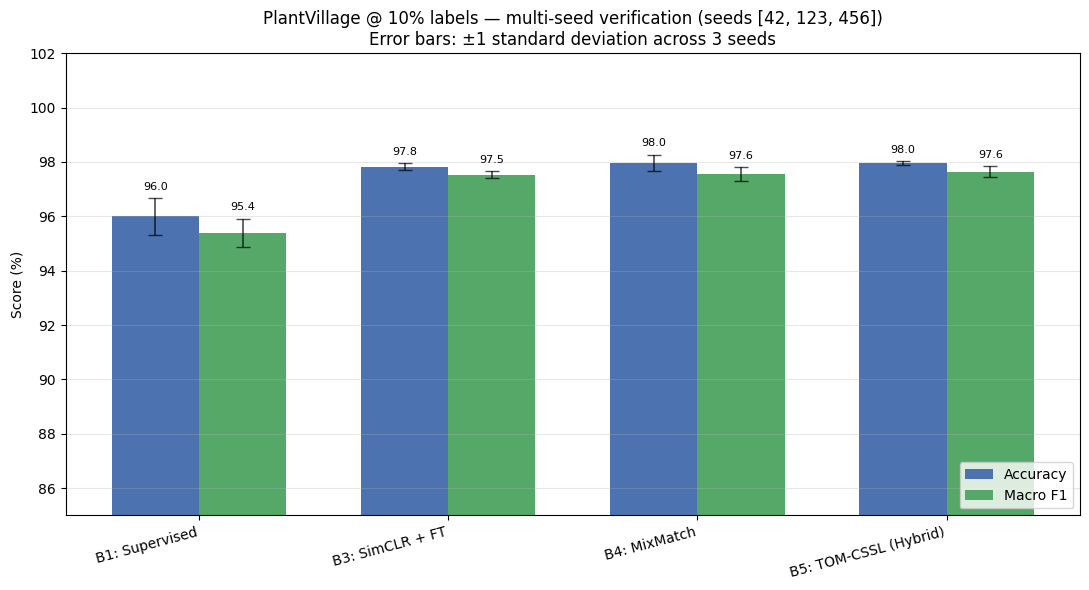


Saved CSV and figure to: /content/drive/MyDrive/Tomato_3regime/RESULTS 2/MULTISEED_PV_10PCT


In [ ]:
# Aggregates results from seeds [42, 123, 456] and produces final table + figure
SEEDS = [42, 123, 456]
METHOD_ORDER = ["B1_supervised", "B3_self_supervised", "B4_semi_supervised", "B5_hybrid"]
METHOD_DISPLAY = {
    "B1_supervised":      "B1: Supervised",
    "B3_self_supervised": "B3: SimCLR + FT",
    "B4_semi_supervised": "B4: MixMatch",
    "B5_hybrid":          "B5: TOM-CSSL (Hybrid)",
}

def folder_for_seed(seed):
    # Seed 42 lives in 10pct/ (the original PV notebook output)
    # Seeds 123 and 456 live in 10pct_seed{N}/
    if seed == 42: return f"{RESULTS_DIR}/10pct"
    return f"{RESULTS_DIR}/10pct_seed{seed}"

# Collect results
results = {m: {"acc": [], "f1": [], "per_seed_acc": [], "per_seed_f1": []}
           for m in METHOD_ORDER}
missing = []
for seed in SEEDS:
    seed_folder = folder_for_seed(seed)
    for method in METHOD_ORDER:
        mpath = f"{seed_folder}/{method}/metrics.json"
        if os.path.exists(mpath):
            with open(mpath) as f: d = json.load(f)
            results[method]["acc"].append(d["overall"]["accuracy"] * 100)
            results[method]["f1"].append(d["overall"]["f1_macro"] * 100)
            results[method]["per_seed_acc"].append((seed, d["overall"]["accuracy"] * 100))
            results[method]["per_seed_f1"].append((seed, d["overall"]["f1_macro"] * 100))
        else:
            missing.append(f"  - {mpath}")

if missing:
    print("WARNING — missing files (will be skipped):")
    for m in missing: print(m)

def msd(vals):
    a = np.array(vals)
    if len(a) == 0: return (float("nan"), float("nan"))
    return a.mean(), (a.std(ddof=1) if len(a) > 1 else 0.0)

# Print table
print("\n" + "=" * 90)
print(f"PLANTVILLAGE 10% MULTI-SEED RESULTS — seeds {SEEDS}")
print("=" * 90)
print(f"  {'Method':<25}  {'Accuracy (%)':<22}  {'Macro F1 (%)':<22}")
print("  " + "-" * 76)
for m in METHOD_ORDER:
    a_m, a_s = msd(results[m]["acc"])
    f_m, f_s = msd(results[m]["f1"])
    print(f"  {METHOD_DISPLAY[m]:<25}  "
          f"{a_m:>6.2f} ± {a_s:>5.2f}        "
          f"{f_m:>6.2f} ± {f_s:>5.2f}")

print("\n  Per-seed accuracy breakdown:")
for m in METHOD_ORDER:
    per_seed_str = "  ".join(f"s{s}={v:.2f}%" for s, v in results[m]["per_seed_acc"])
    print(f"  {METHOD_DISPLAY[m]:<25}  [{per_seed_str}]")

# Save CSV
SUMMARY_DIR = f"{RESULTS_DIR}/MULTISEED_PV_10PCT"
os.makedirs(SUMMARY_DIR, exist_ok=True)
with open(f"{SUMMARY_DIR}/multiseed_summary.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Method", "Metric", "Seed42", "Seed123", "Seed456", "Mean", "Std"])
    for m in METHOD_ORDER:
        for metric in ["acc", "f1"]:
            vals = results[m][metric]
            mean_v, std_v = msd(vals)
            padded = vals + [None] * (3 - len(vals))
            w.writerow([METHOD_DISPLAY[m], metric.upper(),
                        *[f"{v:.2f}" if v is not None else "—" for v in padded],
                        f"{mean_v:.2f}", f"{std_v:.2f}"])

# Figure: mean ± std bars (accuracy and F1 side-by-side)
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(METHOD_ORDER)); w = 0.35

acc_means = [msd(results[m]["acc"])[0] for m in METHOD_ORDER]
acc_stds  = [msd(results[m]["acc"])[1] for m in METHOD_ORDER]
f1_means  = [msd(results[m]["f1"])[0] for m in METHOD_ORDER]
f1_stds   = [msd(results[m]["f1"])[1] for m in METHOD_ORDER]

b1 = ax.bar(x - w/2, acc_means, w, yerr=acc_stds, capsize=5,
            label="Accuracy", color="#4C72B0",
            error_kw={"ecolor": "black", "alpha": 0.7, "lw": 1.2})
b2 = ax.bar(x + w/2, f1_means, w, yerr=f1_stds, capsize=5,
            label="Macro F1", color="#55A868",
            error_kw={"ecolor": "black", "alpha": 0.7, "lw": 1.2})

for bar, m_val, s_val in zip(b1, acc_means, acc_stds):
    ax.text(bar.get_x() + bar.get_width()/2, m_val + s_val + 0.3,
            f"{m_val:.1f}", ha="center", fontsize=8)
for bar, m_val, s_val in zip(b2, f1_means, f1_stds):
    ax.text(bar.get_x() + bar.get_width()/2, m_val + s_val + 0.3,
            f"{m_val:.1f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([METHOD_DISPLAY[m] for m in METHOD_ORDER], rotation=15, ha="right")
ax.set_ylim(85, 102)
ax.set_ylabel("Score (%)")
ax.set_title(f"PlantVillage @ 10% labels — multi-seed verification (seeds {SEEDS})\n"
             f"Error bars: ±1 standard deviation across {len(SEEDS)} seeds")
ax.legend(loc="lower right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/multiseed_accuracy_with_error_bars.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved CSV and figure to: {SUMMARY_DIR}")

In [ ]:
# ============================================================
# PlantVillage 30% Multi-Seed Verification
# Runs seeds [123, 456]; aggregates with existing seed 42 results
# ============================================================
import os, sys, random, copy, time, json, csv, platform
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Torchvision:   {torchvision.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device:        {device}")
if torch.cuda.is_available():
    print(f"GPU:           {torch.cuda.get_device_name(0)}")

# ===== Hyperparameters (identical to original PV notebook) =====
LABEL_PCT       = 0.30
VAL_PCT         = 0.10
IMG_SIZE        = 224
BATCH_SIZE      = 128
NUM_WORKERS     = 2

# SimCLR (already trained — we just load the checkpoint)
SIMCLR_TEMP     = 0.5

# MixMatch
K_AUGMENTS      = 2
SHARPEN_TEMP    = 0.5
MIXUP_ALPHA     = 0.75
LAMBDA_U        = 1.0

# Training
EPOCHS_DEFAULT  = 30
LR_SUP          = 1e-3   # B1
LR_PRETRAINED   = 1e-4   # B3, B4, B5

print(f"\nHyperparameters set (matching original PV notebook).")

Python:        3.12.13
PyTorch:       2.11.0+cu128
Torchvision:   0.26.0+cu128
Device:        cuda
GPU:           Tesla T4

Hyperparameters set (matching original PV notebook).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = "/content/drive/MyDrive/Tomato_3regime"
RESULTS_DIR     = f"{PROJECT_DIR}/RESULTS 2"
SIMCLR_CKPT_SRC = f"{RESULTS_DIR}/simclr/simclr_checkpoint.pth"

assert os.path.exists(SIMCLR_CKPT_SRC), \
    f"SimCLR checkpoint not found at {SIMCLR_CKPT_SRC} — run the main PV notebook first."
print(f"✓ SimCLR checkpoint OK: {SIMCLR_CKPT_SRC}")

# Verify seed 42 results exist (we'll aggregate them with new seeds)
SEED42_PATH = f"{RESULTS_DIR}/30pct"
seed42_methods = ["B1_supervised", "B3_self_supervised",
                  "B4_semi_supervised", "B5_hybrid"]
missing = [m for m in seed42_methods
           if not os.path.exists(f"{SEED42_PATH}/{m}/metrics.json")]
if missing:
    print(f"⚠ Missing seed-42 results for: {missing}")
    print(f"  (Aggregation cell will skip them. New seeds 123/456 will still run.)")
else:
    print(f"✓ Seed-42 results found at: {SEED42_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ SimCLR checkpoint OK: /content/drive/MyDrive/Tomato_3regime/RESULTS 2/simclr/simclr_checkpoint.pth
✓ Seed-42 results found at: /content/drive/MyDrive/Tomato_3regime/RESULTS 2/30pct


In [ ]:
# Colab's local disk is wiped on disconnect, so we rebuild it.
# This downloads PlantVillage from Kaggle if not already present.

if not os.path.exists("/content/TomatoDataset"):
    # Try Kaggle download
    if not os.path.exists("/content/PlantVillage"):
        !pip install -q kaggle
        from google.colab import files
        print("Upload kaggle.json (Kaggle → Account → Create API Token):")
        files.upload()
        !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
        !kaggle datasets download -d emmarex/plantdisease
        !unzip -q plantdisease.zip -d /content/
        print("Dataset downloaded.")

    import shutil
    DATASET_PATH = "/content/PlantVillage"
    TOMATO_PATH  = "/content/TomatoDataset"
    tomato_classes = sorted([c for c in os.listdir(DATASET_PATH) if c.startswith("Tomato")])
    os.makedirs(TOMATO_PATH, exist_ok=True)
    for cls in tomato_classes:
        shutil.copytree(os.path.join(DATASET_PATH, cls), os.path.join(TOMATO_PATH, cls))
    print(f"Tomato subset created at {TOMATO_PATH}")
else:
    TOMATO_PATH = "/content/TomatoDataset"
    print(f"Tomato subset already present at {TOMATO_PATH}")

# Verify
classes_found = sorted([d for d in os.listdir(TOMATO_PATH)
                        if os.path.isdir(os.path.join(TOMATO_PATH, d))])
total = sum(len(os.listdir(os.path.join(TOMATO_PATH, c))) for c in classes_found)
print(f"\nFound {len(classes_found)} class folders, {total} total images")
for c in classes_found:
    n = len(os.listdir(os.path.join(TOMATO_PATH, c)))
    print(f"  {c:<35} {n:>5}")

Tomato subset already present at /content/TomatoDataset

Found 10 class folders, 16012 total images
  Tomato_Bacterial_spot                2127
  Tomato_Early_blight                  1000
  Tomato_Late_blight                   1909
  Tomato_Leaf_Mold                      952
  Tomato_Septoria_leaf_spot            1771
  Tomato_Spider_mites_Two_spotted_spider_mite  1676
  Tomato__Target_Spot                  1404
  Tomato__Tomato_YellowLeaf__Curl_Virus  3209
  Tomato__Tomato_mosaic_virus           373
  Tomato_healthy                       1591


In [ ]:
# Transforms (matching original PV notebook)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
weak_transform = train_transform

class LabeledSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset; self.indices = indices; self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

class UnlabeledKAug(Dataset):
    def __init__(self, base_dataset, indices, transform, K=2):
        self.base = base_dataset; self.indices = indices
        self.transform = transform; self.K = K
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        path, _ = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return [self.transform(img) for _ in range(self.K)]

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def empty_cache():
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def sharpen(p, T=0.5):
    p = p.pow(1.0 / T)
    return p / p.sum(dim=1, keepdim=True)

def mixup(x1, y1, x2, y2, alpha=0.75):
    lam = np.random.beta(alpha, alpha); lam = max(lam, 1 - lam)
    return lam * x1 + (1 - lam) * x2, lam * y1 + (1 - lam) * y2

def stratified_split_with_floor(dataset, label_pct=0.10, val_pct=0.10,
                                 min_per_class=10, seed=42):
    rng = random.Random(seed)
    class_indices = {}
    for idx in range(len(dataset)):
        _, label = dataset.samples[idx]
        class_indices.setdefault(label, []).append(idx)
    labeled_idx, unlabeled_idx, val_idx = [], [], []
    for label, indices in class_indices.items():
        rng.shuffle(indices)
        n = len(indices)
        n_label = max(min_per_class, int(label_pct * n))
        n_val   = max(min_per_class, int(val_pct * n))
        labeled_idx.extend(indices[:n_label])
        val_idx.extend(indices[n_label:n_label + n_val])
        unlabeled_idx.extend(indices[n_label + n_val:])
    return labeled_idx, unlabeled_idx, val_idx

# Build base dataset
base_dataset = ImageFolder(root=TOMATO_PATH)
NUM_CLASSES = len(base_dataset.classes)
print(f"Classes ({NUM_CLASSES}): {base_dataset.classes}")
print(f"Total images: {len(base_dataset)}")

Classes (10): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total images: 16011


In [ ]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        y_pred.append(model(imgs).argmax(1).cpu().numpy())
        y_true.append(labels.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)

def plot_confusion_matrix(cm, class_names, save_path, title="Confusion Matrix"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, mat, sub, fmt in [(axes[0], cm, "Counts", "d"),
                              (axes[1], cm_norm, "Normalized", ".2f")]:
        im = ax.imshow(mat, cmap="Blues", aspect="auto")
        ax.set_title(f"{title} — {sub}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels([c[:20] for c in class_names], rotation=45, ha="right")
        ax.set_yticklabels([c[:20] for c in class_names])
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat[i, j]
                color = "white" if v > mat.max() * 0.55 else "black"
                ax.text(j, i, format(v, fmt), ha="center", va="center", color=color, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.close(fig)

def plot_training_curves(history, save_path, method_name):
    epochs = history.get("epoch", [])
    has_lx = "loss_x" in history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if has_lx:
        axes[0].plot(epochs, history["loss_x"], marker="o", label="labeled (lx)")
        axes[0].plot(epochs, history["loss_u"], marker="s", label="unlabeled (lu)")
    else:
        axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{method_name} — training loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history["val_acc"], marker="o", color="tab:green")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val accuracy (%)")
    axes[1].set_title(f"{method_name} — validation accuracy"); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.close(fig)

def full_evaluation(model, loader, class_names, method_name, history, out_dir, pct_tag, seed_val):
    os.makedirs(out_dir, exist_ok=True)
    y_true, y_pred = collect_predictions(model, loader, device)
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    p_cls, r_cls, f1_cls, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    acc_cls = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    metrics = {
        "method": method_name, "pct_tag": pct_tag, "seed": seed_val,
        "overall": {
            "accuracy": float(acc),
            "precision_macro": float(p_macro), "recall_macro": float(r_macro),
            "f1_macro": float(f1_macro),
            "precision_weighted": float(p_weight), "recall_weighted": float(r_weight),
            "f1_weighted": float(f1_weight),
        },
        "per_class": {
            "class_names": list(class_names),
            "accuracy": acc_cls.tolist(), "precision": p_cls.tolist(),
            "recall": r_cls.tolist(), "f1": f1_cls.tolist(), "support": support.tolist(),
        },
        "confusion_matrix": cm.tolist(),
        "history": history,
        "best_val_acc": max(history.get("val_acc", [0.0])),
    }
    with open(f"{out_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
    report = classification_report(y_true, y_pred, labels=range(len(class_names)),
                                    target_names=class_names, digits=4, zero_division=0)
    with open(f"{out_dir}/classification_report.txt", "w") as f:
        f.write(f"Method: {method_name}   Label %: {pct_tag}   Seed: {seed_val}\n")
        f.write("=" * 80 + "\n"); f.write(report)
        f.write("\n\nConfusion matrix (rows=true, cols=pred):\n"); f.write(str(cm))
    plot_confusion_matrix(cm, class_names, f"{out_dir}/confusion_matrix.png",
                          title=f"{method_name} @ {pct_tag} seed={seed_val}")
    plot_training_curves(history, f"{out_dir}/training_curves.png",
                         f"{method_name} @ {pct_tag} seed={seed_val}")
    return metrics

print("Metrics utilities loaded.")

Metrics utilities loaded.


In [ ]:
class SimCLRModel(nn.Module):
    def __init__(self, feature_dim=128, init="imagenet"):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if init == "imagenet" else None
        self.encoder = models.resnet18(weights=weights)
        self.encoder.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(inplace=True),
            nn.Linear(256, feature_dim),
        )
    def forward(self, x):
        h = self.encoder(x); z = self.projector(h)
        return h, z

simclr_ckpt = torch.load(SIMCLR_CKPT_SRC, map_location=device, weights_only=False)
print(f"SimCLR checkpoint loaded.")
if "final_loss" in simclr_ckpt:
    print(f"  Final NT-Xent loss: {simclr_ckpt['final_loss']:.4f}")
if "epoch" in simclr_ckpt:
    print(f"  Epochs trained:     {simclr_ckpt['epoch']}")

SimCLR checkpoint loaded.
  Final NT-Xent loss: 3.7202
  Epochs trained:     10


In [ ]:
# ==============================================================================
# MULTI-SEED SWEEP — PlantVillage 10% labels, seeds 123 and 456
# Seed 42 was done in the main notebook. We aggregate all three in Cell 8.
# ==============================================================================
SEEDS_TO_RUN = [123, 456]

print(f"PlantVillage 10% Multi-Seed Verification")
print(f"Seeds to run: {SEEDS_TO_RUN}  (seed 42 already done in main notebook)\n")

overall_start = time.time()

for SEED_CUR in SEEDS_TO_RUN:
    print("\n" + "█" * 80)
    print(f"█  PV 30pct  ·  SEED {SEED_CUR}")
    print("█" * 80)

    pct_tag = "30pct"
    CUR_OUT = f"{RESULTS_DIR}/{pct_tag}_seed{SEED_CUR}"
    for method in ["B1_supervised", "B3_self_supervised",
                   "B4_semi_supervised", "B5_hybrid"]:
        os.makedirs(f"{CUR_OUT}/{method}", exist_ok=True)
    os.makedirs(f"{RESULTS_DIR}/splits", exist_ok=True)

    # Build split with this seed
    set_seed(SEED_CUR)
    labeled_idx, unlabeled_idx, val_idx = stratified_split_with_floor(
        base_dataset, label_pct=LABEL_PCT, val_pct=VAL_PCT,
        min_per_class=10, seed=SEED_CUR,
    )
    total_n = len(base_dataset)
    print(f"  Split: lab={len(labeled_idx)} ({100*len(labeled_idx)/total_n:.2f}%)  "
          f"unl={len(unlabeled_idx)} ({100*len(unlabeled_idx)/total_n:.2f}%)  "
          f"val={len(val_idx)} ({100*len(val_idx)/total_n:.2f}%)")

    with open(f"{RESULTS_DIR}/splits/split_{pct_tag}_seed{SEED_CUR}.json", "w") as f:
        json.dump({"seed": SEED_CUR, "label_pct": LABEL_PCT, "val_pct": VAL_PCT,
                   "labeled_idx": labeled_idx, "unlabeled_idx": unlabeled_idx,
                   "val_idx": val_idx, "classes": base_dataset.classes}, f)

    labeled_dataset   = LabeledSubset(base_dataset, labeled_idx,   weak_transform)
    unlabeled_dataset = UnlabeledKAug(base_dataset, unlabeled_idx, weak_transform, K=K_AUGMENTS)
    val_dataset       = LabeledSubset(base_dataset, val_idx,       eval_transform)
    labeled_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    train_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

    # ===== B1: Supervised =====
    set_seed(SEED_CUR)
    sup_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    sup_model.fc = nn.Linear(512, NUM_CLASSES); sup_model = sup_model.to(device)
    optimizer = torch.optim.Adam(sup_model.parameters(), lr=LR_SUP)
    criterion = nn.CrossEntropyLoss()
    hist = {"epoch": [], "train_loss": [], "val_acc": []}
    best, best_state = 0.0, None
    print(f"  Training B1 (seed {SEED_CUR})...", end="", flush=True)
    t0 = time.time()
    for epoch in range(EPOCHS_DEFAULT):
        sup_model.train(); tl, nb = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(sup_model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tl += loss.item(); nb += 1
        sup_model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (sup_model(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        hist["epoch"].append(epoch+1); hist["train_loss"].append(tl/nb); hist["val_acc"].append(val_acc)
        if val_acc > best: best = val_acc; best_state = copy.deepcopy(sup_model.state_dict())
    sup_model.load_state_dict(best_state)
    full_evaluation(sup_model, val_loader, base_dataset.classes, "B1_supervised",
                    hist, f"{CUR_OUT}/B1_supervised", pct_tag, SEED_CUR)
    print(f" best={best:.2f}%  ({(time.time()-t0)/60:.1f}m)")
    del sup_model, optimizer; empty_cache()

    # ===== B3: SimCLR + Full FT =====
    set_seed(SEED_CUR)
    simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])
    class SimCLRFineTune(nn.Module):
        def __init__(self, enc, n):
            super().__init__(); self.encoder = copy.deepcopy(enc); self.classifier = nn.Linear(512, n)
        def forward(self, x): return self.classifier(self.encoder(x))
    ft_model = SimCLRFineTune(simclr_clean.encoder, NUM_CLASSES).to(device)
    optimizer = torch.optim.Adam(ft_model.parameters(), lr=LR_PRETRAINED)
    criterion = nn.CrossEntropyLoss()
    hist = {"epoch": [], "train_loss": [], "val_acc": []}
    best, best_state = 0.0, None
    print(f"  Training B3 (seed {SEED_CUR})...", end="", flush=True)
    t0 = time.time()
    for epoch in range(EPOCHS_DEFAULT):
        ft_model.train(); tl, nb = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(ft_model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tl += loss.item(); nb += 1
        ft_model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (ft_model(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        hist["epoch"].append(epoch+1); hist["train_loss"].append(tl/nb); hist["val_acc"].append(val_acc)
        if val_acc > best: best = val_acc; best_state = copy.deepcopy(ft_model.state_dict())
    ft_model.load_state_dict(best_state)
    full_evaluation(ft_model, val_loader, base_dataset.classes, "B3_self_supervised",
                    hist, f"{CUR_OUT}/B3_self_supervised", pct_tag, SEED_CUR)
    print(f" best={best:.2f}%  ({(time.time()-t0)/60:.1f}m)")
    del ft_model, optimizer, simclr_clean; empty_cache()

    # ===== B4: MixMatch =====
    set_seed(SEED_CUR)
    mm_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    mm_model.fc = nn.Linear(512, NUM_CLASSES); mm_model = mm_model.to(device)
    optimizer = torch.optim.Adam(mm_model.parameters(), lr=LR_PRETRAINED)
    hist = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
    best, best_state = 0.0, None
    print(f"  Training B4 (seed {SEED_CUR})...", end="", flush=True)
    t0 = time.time()
    for epoch in range(EPOCHS_DEFAULT):
        mm_model.train(); tlx, tlu, nb = 0.0, 0.0, 0
        uiter = iter(unlabeled_loader)
        for bx, by in labeled_loader:
            try: buv = next(uiter)
            except StopIteration: uiter = iter(unlabeled_loader); buv = next(uiter)
            bx, by = bx.to(device), by.to(device); buv = [v.to(device) for v in buv]
            with torch.no_grad():
                probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
                for v in buv: probs += F.softmax(mm_model(v), dim=1)
                probs /= len(buv); pseudo = sharpen(probs, T=SHARPEN_TEMP)
            loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
            ai = torch.cat([bx]+buv, dim=0); at = torch.cat([loh]+[pseudo]*len(buv), dim=0)
            si = torch.randperm(ai.size(0))
            mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)
            n = bx.size(0); xp, yp = mx[:n], my[:n]; up, uy = mx[n:], my[n:]
            lx = -torch.mean(torch.sum(yp * F.log_softmax(mm_model(xp), dim=1), dim=1))
            lu = F.mse_loss(F.softmax(mm_model(up), dim=1), uy)
            loss = lx + LAMBDA_U * lu
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tlx += lx.item(); tlu += lu.item(); nb += 1
        mm_model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (mm_model(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        hist["epoch"].append(epoch+1); hist["loss_x"].append(tlx/nb)
        hist["loss_u"].append(tlu/nb); hist["val_acc"].append(val_acc)
        if val_acc > best: best = val_acc; best_state = copy.deepcopy(mm_model.state_dict())
    mm_model.load_state_dict(best_state)
    full_evaluation(mm_model, val_loader, base_dataset.classes, "B4_semi_supervised",
                    hist, f"{CUR_OUT}/B4_semi_supervised", pct_tag, SEED_CUR)
    print(f" best={best:.2f}%  ({(time.time()-t0)/60:.1f}m)")
    del mm_model, optimizer; empty_cache()

    # ===== B5: Hybrid (TOM-CSSL) =====
    set_seed(SEED_CUR)
    simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])
    class SimCLRMixMatchFull(nn.Module):
        def __init__(self, enc, n):
            super().__init__(); self.encoder = copy.deepcopy(enc); self.classifier = nn.Linear(512, n)
        def forward(self, x): return self.classifier(self.encoder(x))
    b5 = SimCLRMixMatchFull(simclr_clean.encoder, NUM_CLASSES).to(device)
    optimizer = torch.optim.Adam(b5.parameters(), lr=LR_PRETRAINED)
    hist = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
    best, best_state = 0.0, None
    print(f"  Training B5 (seed {SEED_CUR})...", end="", flush=True)
    t0 = time.time()
    for epoch in range(EPOCHS_DEFAULT):
        b5.train(); tlx, tlu, nb = 0.0, 0.0, 0
        uiter = iter(unlabeled_loader)
        for bx, by in labeled_loader:
            try: buv = next(uiter)
            except StopIteration: uiter = iter(unlabeled_loader); buv = next(uiter)
            bx, by = bx.to(device), by.to(device); buv = [v.to(device) for v in buv]
            with torch.no_grad():
                probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
                for v in buv: probs += F.softmax(b5(v), dim=1)
                probs /= len(buv); pseudo = sharpen(probs, T=SHARPEN_TEMP)
            loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
            ai = torch.cat([bx]+buv, dim=0); at = torch.cat([loh]+[pseudo]*len(buv), dim=0)
            si = torch.randperm(ai.size(0))
            mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)
            n = bx.size(0); xp, yp = mx[:n], my[:n]; up, uy = mx[n:], my[n:]
            lx = -torch.mean(torch.sum(yp * F.log_softmax(b5(xp), dim=1), dim=1))
            lu = F.mse_loss(F.softmax(b5(up), dim=1), uy)
            loss = lx + LAMBDA_U * lu
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tlx += lx.item(); tlu += lu.item(); nb += 1
        b5.eval(); correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (b5(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        hist["epoch"].append(epoch+1); hist["loss_x"].append(tlx/nb)
        hist["loss_u"].append(tlu/nb); hist["val_acc"].append(val_acc)
        if val_acc > best: best = val_acc; best_state = copy.deepcopy(b5.state_dict())
    b5.load_state_dict(best_state)
    full_evaluation(b5, val_loader, base_dataset.classes, "B5_hybrid",
                    hist, f"{CUR_OUT}/B5_hybrid", pct_tag, SEED_CUR)
    print(f" best={best:.2f}%  ({(time.time()-t0)/60:.1f}m)")
    del b5, optimizer, simclr_clean; empty_cache()

print(f"\n{'='*80}")
print(f"Multi-seed sweep complete. Total: {(time.time()-overall_start)/60:.1f} min")
print(f"{'='*80}")

PlantVillage 10% Multi-Seed Verification
Seeds to run: [123, 456]  (seed 42 already done in main notebook)


████████████████████████████████████████████████████████████████████████████████
█  PV 30pct  ·  SEED 123
████████████████████████████████████████████████████████████████████████████████
  Split: lab=4799 (29.97%)  unl=9615 (60.05%)  val=1597 (9.97%)
  Training B1 (seed 123)... best=98.62%  (12.4m)
  Training B3 (seed 123)... best=99.06%  (11.9m)
  Training B4 (seed 123)... best=99.44%  (31.2m)
  Training B5 (seed 123)... best=99.31%  (31.1m)

████████████████████████████████████████████████████████████████████████████████
█  PV 30pct  ·  SEED 456
████████████████████████████████████████████████████████████████████████████████
  Split: lab=4799 (29.97%)  unl=9615 (60.05%)  val=1597 (9.97%)
  Training B1 (seed 456)... best=98.37%  (11.8m)
  Training B3 (seed 456)... best=99.44%  (12.1m)
  Training B4 (seed 456)... best=99.69%  (31.1m)
  Training B5 (seed 456)... best=99.56%  (31.


PLANTVILLAGE 10% MULTI-SEED RESULTS — seeds [42, 123, 456]
  Method                     Accuracy (%)            Macro F1 (%)          
  ----------------------------------------------------------------------------
  B1: Supervised              98.58 ±  0.19         98.29 ±  0.20
  B3: SimCLR + FT             99.39 ±  0.32         99.23 ±  0.48
  B4: MixMatch                99.56 ±  0.13         99.39 ±  0.26
  B5: TOM-CSSL (Hybrid)       99.54 ±  0.22         99.37 ±  0.46

  Per-seed accuracy breakdown:
  B1: Supervised             [s42=98.75%  s123=98.62%  s456=98.37%]
  B3: SimCLR + FT            [s42=99.69%  s123=99.06%  s456=99.44%]
  B4: MixMatch               [s42=99.56%  s123=99.44%  s456=99.69%]
  B5: TOM-CSSL (Hybrid)      [s42=99.75%  s123=99.31%  s456=99.56%]


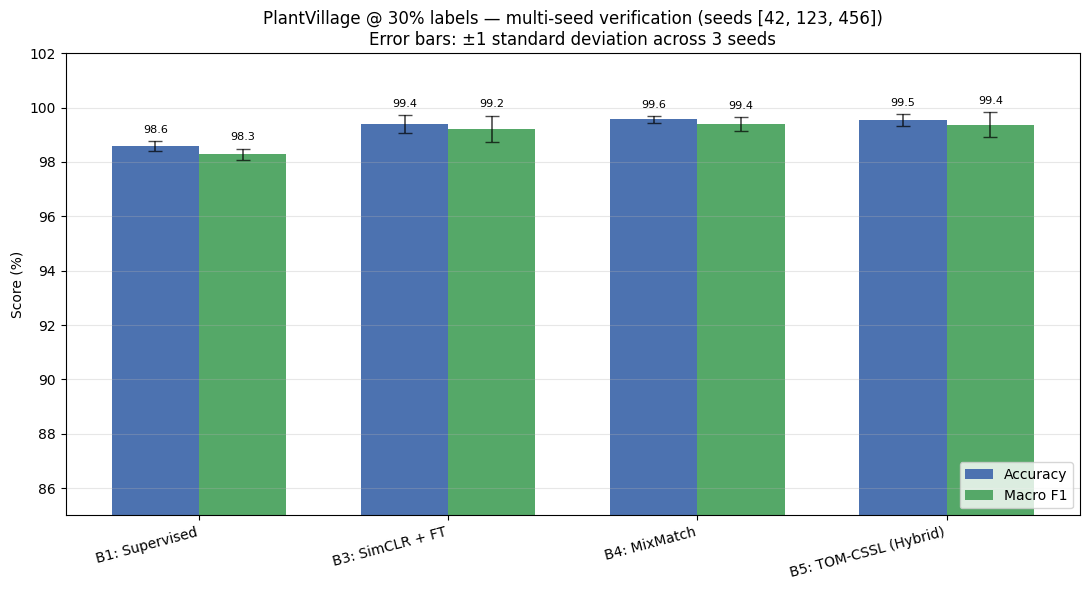


Saved CSV and figure to: /content/drive/MyDrive/Tomato_3regime/RESULTS 2/MULTISEED_PV_30PCT


In [ ]:
# Aggregates results from seeds [42, 123, 456] and produces final table + figure
SEEDS = [42, 123, 456]
METHOD_ORDER = ["B1_supervised", "B3_self_supervised", "B4_semi_supervised", "B5_hybrid"]
METHOD_DISPLAY = {
    "B1_supervised":      "B1: Supervised",
    "B3_self_supervised": "B3: SimCLR + FT",
    "B4_semi_supervised": "B4: MixMatch",
    "B5_hybrid":          "B5: TOM-CSSL (Hybrid)",
}

def folder_for_seed(seed):
    # Seed 42 lives in 30pct/ (the original PV notebook output)
    # Seeds 123 and 456 live in 30pct_seed{N}/
    if seed == 42: return f"{RESULTS_DIR}/30pct"
    return f"{RESULTS_DIR}/30pct_seed{seed}"

# Collect results
results = {m: {"acc": [], "f1": [], "per_seed_acc": [], "per_seed_f1": []}
           for m in METHOD_ORDER}
missing = []
for seed in SEEDS:
    seed_folder = folder_for_seed(seed)
    for method in METHOD_ORDER:
        mpath = f"{seed_folder}/{method}/metrics.json"
        if os.path.exists(mpath):
            with open(mpath) as f: d = json.load(f)
            results[method]["acc"].append(d["overall"]["accuracy"] * 100)
            results[method]["f1"].append(d["overall"]["f1_macro"] * 100)
            results[method]["per_seed_acc"].append((seed, d["overall"]["accuracy"] * 100))
            results[method]["per_seed_f1"].append((seed, d["overall"]["f1_macro"] * 100))
        else:
            missing.append(f"  - {mpath}")

if missing:
    print("WARNING — missing files (will be skipped):")
    for m in missing: print(m)

def msd(vals):
    a = np.array(vals)
    if len(a) == 0: return (float("nan"), float("nan"))
    return a.mean(), (a.std(ddof=1) if len(a) > 1 else 0.0)

# Print table
print("\n" + "=" * 90)
print(f"PLANTVILLAGE 10% MULTI-SEED RESULTS — seeds {SEEDS}")
print("=" * 90)
print(f"  {'Method':<25}  {'Accuracy (%)':<22}  {'Macro F1 (%)':<22}")
print("  " + "-" * 76)
for m in METHOD_ORDER:
    a_m, a_s = msd(results[m]["acc"])
    f_m, f_s = msd(results[m]["f1"])
    print(f"  {METHOD_DISPLAY[m]:<25}  "
          f"{a_m:>6.2f} ± {a_s:>5.2f}        "
          f"{f_m:>6.2f} ± {f_s:>5.2f}")

print("\n  Per-seed accuracy breakdown:")
for m in METHOD_ORDER:
    per_seed_str = "  ".join(f"s{s}={v:.2f}%" for s, v in results[m]["per_seed_acc"])
    print(f"  {METHOD_DISPLAY[m]:<25}  [{per_seed_str}]")

# Save CSV
SUMMARY_DIR = f"{RESULTS_DIR}/MULTISEED_PV_30PCT"
os.makedirs(SUMMARY_DIR, exist_ok=True)
with open(f"{SUMMARY_DIR}/multiseed_summary.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Method", "Metric", "Seed42", "Seed123", "Seed456", "Mean", "Std"])
    for m in METHOD_ORDER:
        for metric in ["acc", "f1"]:
            vals = results[m][metric]
            mean_v, std_v = msd(vals)
            padded = vals + [None] * (3 - len(vals))
            w.writerow([METHOD_DISPLAY[m], metric.upper(),
                        *[f"{v:.2f}" if v is not None else "—" for v in padded],
                        f"{mean_v:.2f}", f"{std_v:.2f}"])

# Figure: mean ± std bars (accuracy and F1 side-by-side)
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(METHOD_ORDER)); w = 0.35

acc_means = [msd(results[m]["acc"])[0] for m in METHOD_ORDER]
acc_stds  = [msd(results[m]["acc"])[1] for m in METHOD_ORDER]
f1_means  = [msd(results[m]["f1"])[0] for m in METHOD_ORDER]
f1_stds   = [msd(results[m]["f1"])[1] for m in METHOD_ORDER]

b1 = ax.bar(x - w/2, acc_means, w, yerr=acc_stds, capsize=5,
            label="Accuracy", color="#4C72B0",
            error_kw={"ecolor": "black", "alpha": 0.7, "lw": 1.2})
b2 = ax.bar(x + w/2, f1_means, w, yerr=f1_stds, capsize=5,
            label="Macro F1", color="#55A868",
            error_kw={"ecolor": "black", "alpha": 0.7, "lw": 1.2})

for bar, m_val, s_val in zip(b1, acc_means, acc_stds):
    ax.text(bar.get_x() + bar.get_width()/2, m_val + s_val + 0.3,
            f"{m_val:.1f}", ha="center", fontsize=8)
for bar, m_val, s_val in zip(b2, f1_means, f1_stds):
    ax.text(bar.get_x() + bar.get_width()/2, m_val + s_val + 0.3,
            f"{m_val:.1f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([METHOD_DISPLAY[m] for m in METHOD_ORDER], rotation=15, ha="right")
ax.set_ylim(85, 102)
ax.set_ylabel("Score (%)")
ax.set_title(f"PlantVillage @ 30% labels — multi-seed verification (seeds {SEEDS})\n"
             f"Error bars: ±1 standard deviation across {len(SEEDS)} seeds")
ax.legend(loc="lower right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/multiseed_accuracy_with_error_bars.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved CSV and figure to: {SUMMARY_DIR}")